In [ ]:
!wget -q https://huggingface.co/datasets/garythung/trashnet/resolve/main/dataset-resized.zip -O dataset-resized.zip
!unzip -q -o dataset-resized.zip -d _raw
!mkdir -p dataset
import shutil, os
src_root = "_raw/dataset-resized"
for cls in ["glass","paper","cardboard","plastic","metal","trash"]:
    dst = f"dataset/{cls}"
    if os.path.exists(dst):
        shutil.rmtree(dst)
    shutil.copytree(f"{src_root}/{cls}", dst)
    print(cls, "->", len(os.listdir(dst)), "images")

glass -> 501 images
paper -> 594 images
cardboard -> 403 images
plastic -> 482 images
metal -> 410 images
trash -> 137 images


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

DATASET_DIR = "dataset"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_STAGE1 = 10
EPOCHS_STAGE2 = 5

TensorFlow version: 2.20.0
GPU available: []


In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR, validation_split=0.2, subset="training",
    seed=123, image_size=IMG_SIZE, batch_size=BATCH_SIZE)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR, validation_split=0.2, subset="validation",
    seed=123, image_size=IMG_SIZE, batch_size=BATCH_SIZE)

class_names = train_ds.class_names
print("Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [ ]:
 data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
])

base_model = MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet")
base_model.trainable = False

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)

model = models.Model(inputs, outputs)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history1 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_STAGE1)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.6083 - loss: 1.0474 - val_accuracy: 0.7743 - val_loss: 0.6054
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.7443 - loss: 0.6591 - val_accuracy: 0.8198 - val_loss: 0.5222
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - accuracy: 0.7943 - loss: 0.5846 - val_accuracy: 0.8475 - val_loss: 0.4695
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - accuracy: 0.8051 - loss: 0.5173 - val_accuracy: 0.8297 - val_loss: 0.4576
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.8200 - loss: 0.4834 - val_accuracy: 0.8495 - val_loss: 0.4746
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.8348 - loss: 0.4411 - val_accuracy: 0.8554 - val_loss: 0.4308
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.8482 - loss: 0.4171 - val_accuracy: 0.8495 - val_loss: 0.4375
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.8615 - loss: 0.3891 - val_accuracy: 0.8574 - v

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history2 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_STAGE2)

Epoch 1/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 183s 3s/step - accuracy: 0.8516 - loss: 0.4094 - val_accuracy: 0.8614 - val_loss: 0.3992
Epoch 2/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.8704 - loss: 0.3571 - val_accuracy: 0.8614 - val_loss: 0.3915
Epoch 3/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - accuracy: 0.8749 - loss: 0.3358 - val_accuracy: 0.8713 - val_loss: 0.3853
Epoch 4/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 205s 2s/step - accuracy: 0.8769 - loss: 0.3492 - val_accuracy: 0.8693 - val_loss: 0.3775
Epoch 5/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 180s 3s/step - accuracy: 0.8788 - loss: 0.3421 - val_accuracy: 0.8653 - val_loss: 0.3793


In [ ]:
model.save("waste_classifier.keras")
print("Saved!")

Saved!


In [ ]:
val_loss, val_acc = model.evaluate(val_ds)
print(f"Final validation accuracy: {val_acc:.2%}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.8653 - loss: 0.3793
Final validation accuracy: 86.53%


In [ ]:
import random
test_model = tf.keras.models.load_model("waste_classifier.keras")

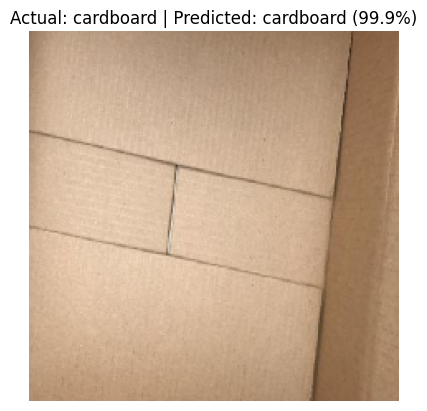

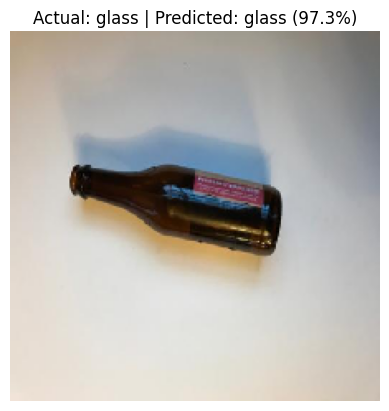

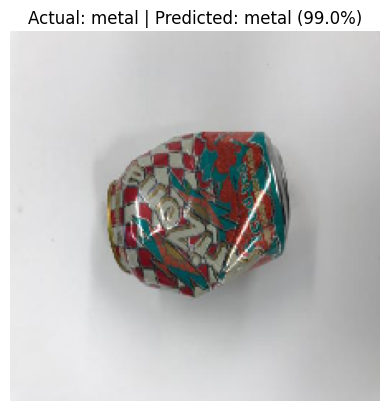

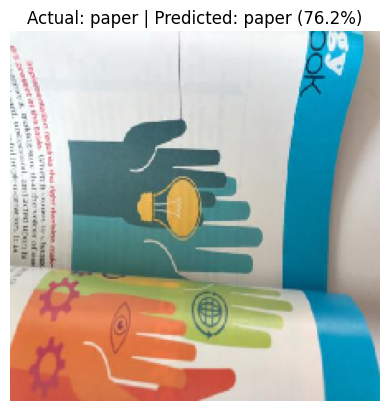

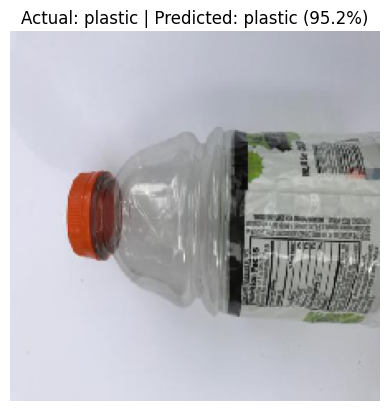

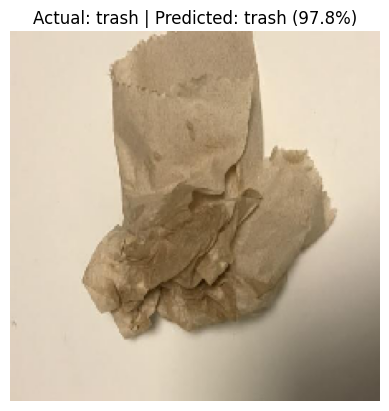

In [ ]:
for cls in class_names:
    folder = f"dataset/{cls}"
    files = os.listdir(folder)
    random.shuffle(files)
    match_found = False
    for sample_file in files:
        img_path = os.path.join(folder, sample_file)
        img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
        img_array = tf.keras.utils.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        preds = test_model.predict(img_array, verbose=0)[0]
        top_idx = np.argmax(preds)
        if class_names[top_idx] == cls:
            plt.imshow(img)
            plt.axis("off")
            plt.title(f"Actual: {cls} | Predicted: {class_names[top_idx]} ({preds[top_idx]:.1%})")
            plt.show()
            match_found = True
            break
    if not match_found:
        print(f"No correct prediction found for class: {cls}")

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_true, y_pred = [], []
for images, labels in val_ds:
    preds = test_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

   cardboard       0.97      0.88      0.92        83
       glass       0.79      0.91      0.85       103
       metal       0.93      0.86      0.89        78
       paper       0.90      0.90      0.90       124
     plastic       0.82      0.84      0.83        88
       trash       0.71      0.59      0.64        29

    accuracy                           0.87       505
   macro avg       0.85      0.83      0.84       505
weighted avg       0.87      0.87      0.87       505



Saving WhatsApp Image 2026-09-27 at 11.34.27 PM.jpeg to WhatsApp Image 2026-09-27 at 11.34.27 PM.jpeg


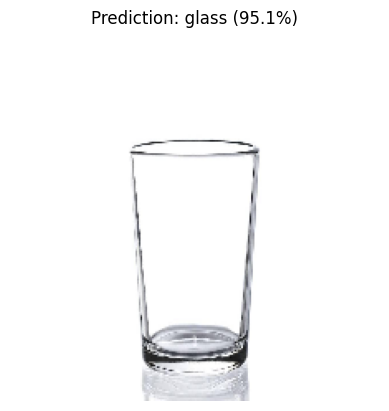

  glass       : 95.14%
  plastic     : 2.58%
  metal       : 1.82%
  paper       : 0.26%
  trash       : 0.11%
  cardboard   : 0.10%


In [ ]:
from google.colab import files
uploaded = files.upload()

img_path = list(uploaded.keys())[0]
img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

preds = test_model.predict(img_array, verbose=0)[0]
top_idx = np.argmax(preds)

plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {class_names[top_idx]} ({preds[top_idx]:.1%})")
plt.show()

for name, prob in sorted(zip(class_names, preds), key=lambda x: -x[1]):
    print(f"  {name:12s}: {prob:.2%}")